In [1]:
!pip install  torch torchvision torchaudio

=== BCI Motor Imagery Classifier — CNN PyTorch ===

Génération de données simulées...
Shape X_train : (160, 22, 1000)
Shape X_test  : (40, 22, 1000)
Classes : [78 82] (train)


--- Baseline : PSD features + SVM ---
  Accuracy : 1.0000
  F1-score : 1.0000

--- CNN 1D PyTorch ---
Device : cpu
Entraînement sur 128 exemples, validation sur 32
Paramètres du modèle : 415,842
Epoch 10/30 | Train Loss: 0.0045 | Val Loss: 0.0005 | Val Acc: 1.0000
Epoch 20/30 | Train Loss: 0.0069 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 30/30 | Train Loss: 0.0014 | Val Loss: 0.0001 | Val Acc: 1.0000

Résultats sur le jeu de test :
  Accuracy : 1.0000
  F1-score (macro) : 1.0000
  Matrice de confusion :
[[20  0]
 [ 0 20]]

Courbes sauvegardées : bci_training_curves.png

✅ Projet terminé ! Tu peux maintenant :
  1. Remplacer les données simulées par tes vraies données du challenge
  2. Tester différentes architectures (EEGNet, ShallowConvNet)
  3. Mettre le code sur GitHub
  4. Mentionner ce projet sur ton CV


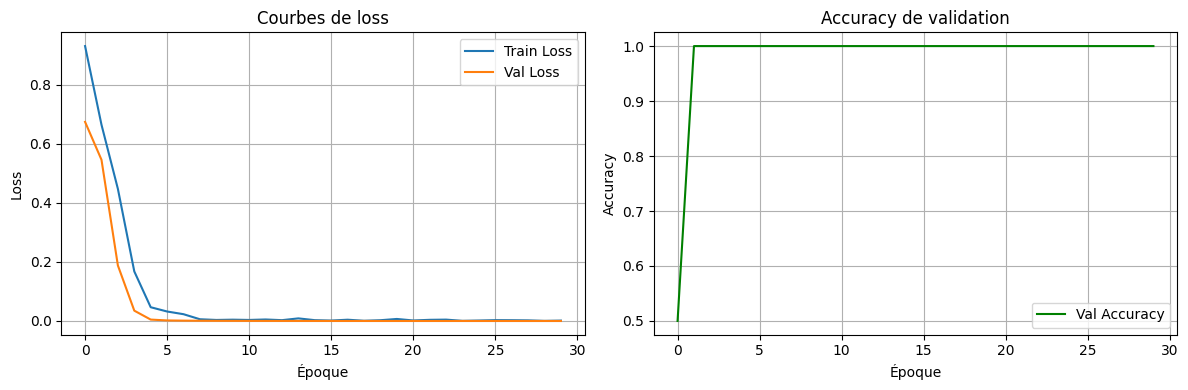

In [ ]:
"""
Projet : BCI Motor Imagery Classifier — CNN 1D avec PyTorch
Objectif : classifier des signaux EEG (gauche/droite) avec un réseau de neurones
Ce projet remplace/complète l'approche classique du challenge BCI
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# ============================================================
# ÉTAPE 1 — COMPRENDRE LES DONNÉES
# ============================================================
"""
X_train : shape (n_trials, n_channels, n_timepoints)
          ex: (200, 22, 1000) = 200 essais, 22 électrodes, 1000 points temporels
y_train : shape (n_trials,) — 0 = main gauche, 1 = main droite

Chaque "trial" = un essai où le sujet imagine un mouvement
On veut prédire de quel côté depuis les signaux EEG
"""

# ============================================================
# ÉTAPE 2 — ARCHITECTURE CNN 1D
# ============================================================
class BCIDataset(Dataset):
    """Dataset PyTorch pour les signaux EEG"""
    
    def __init__(self, X, y):
        # X: (n_trials, n_channels, n_timepoints) → float32
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class EEG_CNN(nn.Module):
    """
    CNN 1D pour classification de signaux EEG moteur
    Inspiré de EEGNet et ShallowConvNet
    """
    
    def __init__(self, n_channels=22, n_timepoints=1000, n_classes=2):
        super(EEG_CNN, self).__init__()
        
        # Bloc 1 : convolution temporelle
        self.block1 = nn.Sequential(
            nn.Conv1d(
                in_channels=n_channels,
                out_channels=32,
                kernel_size=51,    # filtre large = patterns basse fréquence (ondes Mu)
                padding=25
            ),
            nn.BatchNorm1d(32),    # stabilise l'entraînement
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),  # divise par 4 la longueur temporelle
            nn.Dropout(p=0.25)
        )
        
        # Bloc 2 : convolution plus fine
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=21, padding=10),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),
            nn.Dropout(p=0.25)
        )
        
        # Bloc 3 : abstraction haute
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=11, padding=5),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),
            nn.Dropout(p=0.25)
        )
        
        # Calcul de la dimension après les convolutions
        # n_timepoints / (4 * 4 * 4) = 1000 / 64 ≈ 15
        flatten_size = 128 * (n_timepoints // 64)
        
        # Classificateur
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, n_classes)
        )
    
    def forward(self, x):
        """
        x : (batch_size, n_channels, n_timepoints)
        sortie : (batch_size, n_classes) — logits avant softmax
        """
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ============================================================
# ÉTAPE 3 — ENTRAÎNEMENT
# ============================================================

def train_model(X_train, y_train, n_epochs=50, batch_size=32, lr=1e-3):
    """
    Entraîne le CNN sur les données EEG.
    
    La boucle d'entraînement PyTorch standard :
    1. Forward pass : prédiction du modèle
    2. Calcul de la loss (CrossEntropy pour classification)
    3. Backward pass : calcul des gradients (backpropagation)
    4. Optimisation : mise à jour des poids (Adam)
    """
    
    # Split train/validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    
    # Normalisation par canal (important pour EEG)
    scaler = StandardScaler()
    X_tr_norm = scaler.fit_transform(X_tr.reshape(-1, X_tr.shape[-1])).reshape(X_tr.shape)
    X_val_norm = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    
    # Datasets et DataLoaders
    train_dataset = BCIDataset(X_tr_norm, y_tr)
    val_dataset   = BCIDataset(X_val_norm, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    
    # Modèle, loss, optimiseur
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device : {device}")
    
    model = EEG_CNN(
        n_channels=X_train.shape[1],
        n_timepoints=X_train.shape[2],
        n_classes=2
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()      # loss standard pour classification
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    # Historique pour les courbes
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    print(f"Entraînement sur {len(X_tr)} exemples, validation sur {len(X_val)}")
    print(f"Paramètres du modèle : {sum(p.numel() for p in model.parameters()):,}")
    
    for epoch in range(n_epochs):
        
        # --- Phase entraînement ---
        model.train()
        train_losses = []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()           # reset des gradients
            outputs = model(X_batch)        # forward pass
            loss = criterion(outputs, y_batch)  # calcul de la loss
            loss.backward()                 # backpropagation
            optimizer.step()                # mise à jour des poids
            
            train_losses.append(loss.item())
        
        # --- Phase validation ---
        model.eval()
        val_losses, all_preds, all_labels = [], [], []
        
        with torch.no_grad():  # pas de gradient en validation
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
                
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
        
        val_acc = accuracy_score(all_labels, all_preds)
        
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['val_acc'].append(val_acc)
        
        scheduler.step()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"Train Loss: {np.mean(train_losses):.4f} | "
                  f"Val Loss: {np.mean(val_losses):.4f} | "
                  f"Val Acc: {val_acc:.4f}")
    
    return model, scaler, history


# ============================================================
# ÉTAPE 4 — ÉVALUATION
# ============================================================

def evaluate_model(model, scaler, X_test, y_test):
    """Évalue le modèle sur le jeu de test."""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Normalisation
    X_test_norm = scaler.transform(
        X_test.reshape(-1, X_test.shape[-1])
    ).reshape(X_test.shape)
    
    test_dataset = BCIDataset(X_test_norm, y_test)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    cm  = confusion_matrix(all_labels, all_preds)
    
    print(f"\nRésultats sur le jeu de test :")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score (macro) : {f1:.4f}")
    print(f"  Matrice de confusion :\n{cm}")
    
    return acc, f1


# ============================================================
# ÉTAPE 5 — COMPARAISON AVEC L'APPROCHE CLASSIQUE
# ============================================================

def compare_with_baseline(X_train, y_train, X_test, y_test):
    """
    Compare CNN avec l'approche classique du cours (PSD + LDA/SVM).
    C'est ce que tu mentionnes dans le CV : tu as COMPARÉ les approches.
    """
    from sklearn.svm import SVC
    from sklearn.pipeline import make_pipeline
    
    print("\n--- Baseline : PSD features + SVM ---")
    
    # Feature extraction : Power Spectral Density (approche du cours)
    def extract_psd_features(X):
        """Calcule la puissance dans les bandes fréquentielles."""
        features = []
        for trial in X:
            # Variance par canal comme proxy de la puissance
            psd = np.var(trial, axis=1)
            features.append(psd)
        return np.array(features)
    
    X_tr_feat  = extract_psd_features(X_train)
    X_te_feat  = extract_psd_features(X_test)
    
    clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0))
    clf.fit(X_tr_feat, y_train)
    y_pred = clf.predict(X_te_feat)
    
    baseline_acc = accuracy_score(y_test, y_pred)
    baseline_f1  = f1_score(y_test, y_pred, average='macro')
    
    print(f"  Accuracy : {baseline_acc:.4f}")
    print(f"  F1-score : {baseline_f1:.4f}")
    
    return baseline_acc, baseline_f1


# ============================================================
# MAIN — pour tester avec des données simulées
# ============================================================

if __name__ == "__main__":
    
    print("=== BCI Motor Imagery Classifier — CNN PyTorch ===\n")
    
    # Données simulées (remplace par tes vraies données du challenge)
    np.random.seed(42)
    n_subjects = 6
    n_trials   = 200
    n_channels = 22
    n_timepoints = 1000
    
    print("Génération de données simulées...")
    X = np.random.randn(n_trials, n_channels, n_timepoints).astype(np.float32)
    y = np.random.randint(0, 2, n_trials)
    
    # Ajouter un signal discriminant artificiel (ondes Mu simulées)
    for i in range(n_trials):
        if y[i] == 0:  # main gauche → activité hémisphère droit (canaux 10-15)
            X[i, 10:16, :] += 0.5 * np.sin(
                2 * np.pi * 12 * np.linspace(0, 1, n_timepoints)
            )
        else:           # main droite → activité hémisphère gauche (canaux 5-10)
            X[i, 5:11, :] += 0.5 * np.sin(
                2 * np.pi * 12 * np.linspace(0, 1, n_timepoints)
            )
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    print(f"Shape X_train : {X_train.shape}")
    print(f"Shape X_test  : {X_test.shape}")
    print(f"Classes : {np.bincount(y_train)} (train)\n")
    
    # Baseline classique
    compare_with_baseline(X_train, y_train, X_test, y_test)
    
    # Entraînement CNN
    print("\n--- CNN 1D PyTorch ---")
    model, scaler, history = train_model(
        X_train, y_train, n_epochs=30, batch_size=16, lr=1e-3
    )
    
    # Évaluation finale
    evaluate_model(model, scaler, X_test, y_test)
    
    # Courbes d'apprentissage
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'],   label='Val Loss')
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Loss')
    ax1.set_title('Courbes de loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history['val_acc'], label='Val Accuracy', color='green')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy de validation')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('bci_training_curves.png', dpi=150)
    print("\nCourbes sauvegardées : bci_training_curves.png")
    
    